# Radiative cooling: acquisition checks to Random Forest validation

Predict recorded net heat flux from five atmospheric inputs for the Sample 2 RAFT
campaign. This executed notebook includes acquisition checks, three-minute alignment
without gap interpolation, a basic Random Forest, two validation protocols, and
20 embedded figures. Run all cells to reproduce the analysis; no separate figure
files are created.

See the [repository README](../README.md) for setup and results,
the [data dictionary](../processed/README.md) for inputs, and the
[methodology and references](../docs/methodology.md) for processing decisions and
the supervisor's instructions. Private recordings are not redistributed or required
to execute this notebook.


## 1. Configuration and provenance

The default `full_campaign` mode uses the April–July merged table. Separate instrument
exports cover only April–May; `native_exports` restricts modelling to those timestamps.
Full-campaign results depend on an earlier merge whose later source timestamps and
matching tolerance are unavailable. Both modes use the existing explicit logger-unit
metadata and inherited calibration. No sensor polarity change is guessed.

The latest guidance permits three-minute alignment and asks for a basic Random Forest.
The older presentation's five-minute MLP example is not the modelling specification
for this baseline. Input hashes and actual package versions are printed below.


In [1]:
%matplotlib inline
from pathlib import Path
import hashlib
import platform
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sklearn
from IPython.display import display, Markdown
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

def find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base, base / 'Dipu_Bhai_Thesis'):
            if (candidate / 'processed/merged_dataset_104957.csv').is_file():
                return candidate
    raise FileNotFoundError('Open this notebook from the project or its code folder.')

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / 'processed'
DATA_SCOPE = 'full_campaign'  # Alternative: 'native_exports'
GRID = '3min'
SEED = 42
VALIDATION_FRACTION = 0.20
CHRONOLOGICAL_GAP = pd.Timedelta('1D')
HEAT_FLUX_SENSITIVITY_V = 60e-6  # V per (W/m²), inherited, not independently certified
FEATURES = ['T_amb', 'RH', 'v', 'G', 'T_sky']
TARGET = 'Q_net'
MODEL_COLS = FEATURES + [TARGET]
PLOT_ORDER = [TARGET, 'G', 'T_amb', 'T_sky', 'RH', 'v']
LABELS = {
    'Q_net': ('Recorded net heat flux', 'Q_net [W/m²]', '#202020'),
    'G': ('Solar irradiance', 'G [W/m²]', '#dc8b12'),
    'T_amb': ('Ambient temperature', 'T_amb [°C]', '#2376b7'),
    'T_sky': ('Sky temperature', 'T_sky [°C]', '#c83d4b'),
    'RH': ('Relative humidity', 'RH [%]', '#329261'),
    'v': ('Wind speed', 'v [m/s]', '#8661b3'),
}
assert DATA_SCOPE in {'full_campaign', 'native_exports'}
plt.rcParams.update({'figure.dpi': 105, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.2})
pd.set_option('display.max_columns', 12)
pd.set_option('display.precision', 4)
versions = pd.Series({'Python': platform.python_version(), 'pandas': pd.__version__,
                      'NumPy': np.__version__, 'Matplotlib': matplotlib.__version__,
                      'scikit-learn': sklearn.__version__}, name='Version')
display(versions.to_frame())
print(f'Scope: {DATA_SCOPE}; grid: {GRID}; random seed: {SEED}')

,Version
Python,3.11.3
pandas,2.1.4
NumPy,1.26.4
Matplotlib,3.10.5
scikit-learn,1.5.2


Scope: full_campaign; grid: 3min; random seed: 42


## 2. Read and inspect the available acquisitions

In [2]:
source_names = {
    'RAFT export': 'merged_raft.csv',
    'Weather export': 'merged_meteo.csv',
    'Sky export': 'merged_ir.csv',
    'Full merged table': 'merged_dataset_104957.csv',
}
source_frames = {name: pd.read_csv(DATA_DIR / filename, low_memory=False)
                 for name, filename in source_names.items()}
raft = source_frames['RAFT export'].copy()
weather = source_frames['Weather export'].copy()
sky = source_frames['Sky export'].copy()
full = source_frames['Full merged table'].copy()
raft['timestamp'] = pd.to_datetime(raft['DATE'].str.strip() + ' ' + raft['TIME'].str.strip(),
                                  format='%d/%m/%Y %H:%M:%S', errors='raise')
# Remove the English weekday and map the English month explicitly (locale-independent).
month_numbers = dict(zip(['January', 'February', 'March', 'April', 'May', 'June',
                         'July', 'August', 'September', 'October', 'November', 'December'],
                        [f'{m:02}' for m in range(1, 13)]))
weather_time = weather['TIME'].str.extract(
    r'^\w+ (\d{1,2}) (\w+) (\d{4}) (\d{2}:\d{2}:\d{2})$')
weather['timestamp'] = pd.to_datetime(
    weather_time[2] + '-' + weather_time[1].map(month_numbers) + '-' +
    weather_time[0].str.zfill(2) + ' ' + weather_time[3], errors='raise')
sky['timestamp'] = pd.to_datetime(sky['TIMESTAMP'], format='mixed', errors='raise')
full['timestamp'] = pd.to_datetime(full['timestamp'], errors='raise')
for name, frame in [('RAFT', raft), ('Weather', weather), ('Sky', sky), ('Full', full)]:
    assert frame['timestamp'].notna().all(), f'{name}: missing/invalid timestamps'
assert not full['timestamp'].duplicated().any(), 'Full table has ambiguous duplicate timestamps.'

def numeric(series):
    return pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan)

for column in MODEL_COLS + ['Q_net_raw', 'Q_net_voltage_V', 'T_pt100_C']:
    full[column] = numeric(full[column])
full = full.sort_values('timestamp').set_index('timestamp')
inventory = []
for name, frame in [('RAFT export', raft), ('Weather export', weather),
                    ('Sky export', sky), ('Full merged table', full.reset_index())]:
    times = frame['timestamp'].sort_values()
    steps = times.diff().dropna()
    inventory.append({'Source': name, 'Rows': len(frame), 'First': times.min(),
                      'Last': times.max(), 'Duplicate timestamps': int(times.duplicated().sum()),
                      'Median positive step (s)': steps[steps > pd.Timedelta(0)].dt.total_seconds().median(),
                      'SHA256': hashlib.sha256((DATA_DIR / source_names[name]).read_bytes()).hexdigest()})
source_inventory = pd.DataFrame(inventory).set_index('Source')
display(source_inventory.drop(columns='SHA256'))
display(source_inventory[['SHA256']])
display(sky.groupby('RECORD_TYPE').agg(rows=('TIMESTAMP', 'size'),
                                      first=('timestamp', 'min'), last=('timestamp', 'max')))

,Rows,First,Last,Duplicate timestamps,Median positive step (s)
Source,,,,,
RAFT export,35132,2026-04-17 14:53:44.000,2026-05-15 12:02:32,0,60.0
Weather export,35327,2026-04-17 14:54:24.000,2026-05-15 12:03:46,4,60.0
Sky export,33890,2026-04-20 09:36:08.788,2026-05-15 12:03:23,0,60.0
Full merged table,104957,2026-04-17 14:53:44.000,2026-07-03 07:59:16,0,60.0


,SHA256
Source,
RAFT export,6fb1a55e183d4c03a06c6427a776e7f6b55f84983bd85b...
Weather export,fc8057c64cc3b1396d8ea9f22598d4ce2dc96650314401...
Sky export,81a249802d48274a28b057c626f386853faa289a92cbc1...
Full merged table,abedc40fb470cb793e3590b4d1d6693f5010bd2ffaa9c2...


,rows,first,last
RECORD_TYPE,,,
DETAILED_DAT,9573,2026-04-20 09:36:08.788,2026-04-28 14:41:11.712
SIMPLE_TXT,24317,2026-04-28 14:46:26.000,2026-05-15 12:03:23.000


### Heat-flux units and duplicate timestamps

In [3]:
raft = raft.sort_values('timestamp').set_index('timestamp')
unit_lookup = full[['Q_raw_unit', 'Q_net_raw']].reindex(raft.index)
raft_raw = numeric(raft['HEAT_FLUX_V'])
assert np.allclose(raft_raw, unit_lookup['Q_net_raw'], equal_nan=True), (
    'RAFT raw values disagree with the exact-timestamp unit metadata source.')
unit_scale = unit_lookup['Q_raw_unit'].map({'V': 1.0, 'uV': 1e-6})
assert unit_scale[raft_raw.notna()].notna().all(), 'Unknown unit for a finite RAFT value.'
raft_voltage = raft_raw * unit_scale
raft_flux = raft_voltage / HEAT_FLUX_SENSITIVITY_V
known = full['Q_raw_unit'].map({'V': 1.0, 'uV': 1e-6})
assert known[full['Q_net_raw'].notna()].notna().all()
assert np.allclose(full['Q_net_raw'] * known, full['Q_net_voltage_V'], equal_nan=True)
assert np.allclose(full['Q_net_voltage_V'] / HEAT_FLUX_SENSITIVITY_V,
                   full[TARGET], equal_nan=True)
assert np.allclose(raft_flux, full[TARGET].reindex(raft.index), equal_nan=True)
display(pd.DataFrame({'Rows': full.groupby('Q_raw_unit', dropna=False).size()}))
print('Raw-to-voltage and voltage-to-flux arithmetic agree with the existing full table.')
print('The sign and calibration coefficient remain inherited measurement assumptions.')

weather = weather.sort_values('timestamp').set_index('timestamp')
sky = sky.sort_values('timestamp').set_index('timestamp')
assert sky['RECORD_TYPE'].isin(['SIMPLE_TXT', 'DETAILED_DAT']).all()
sky_temperature = numeric(sky['TEMPERATURE_C']).where(
    sky['RECORD_TYPE'].eq('SIMPLE_TXT'), numeric(sky['TPROC']))
native_series = {TARGET: raft_flux, 'T_sky': sky_temperature}
for original, name in {'TEMP': 'T_amb', 'RH': 'RH', 'SPEED': 'v', 'SOLARRAD': 'G'}.items():
    native_series[name] = numeric(weather[original])
native_series = {name: series.groupby(level=0).mean().sort_index().rename(name)
                 for name, series in native_series.items()}
native_full = pd.concat(native_series, axis=1).sort_index()[MODEL_COLS]
display(pd.DataFrame({name: {'readings': len(series), 'finite': int(series.notna().sum()),
                            'missing': int(series.isna().sum())}
                      for name, series in native_series.items()}).T)

,Rows
Q_raw_unit,
V,1488
missing,1
uV,103468


Raw-to-voltage and voltage-to-flux arithmetic agree with the existing full table.
The sign and calibration coefficient remain inherited measurement assumptions.


,readings,finite,missing
Q_net,35132,35131,1
T_sky,33890,33890,0
T_amb,35323,35323,0
RH,35323,35323,0
v,35323,35323,0
G,35323,35323,0


### Original-timestamp plots, before modelling preprocessing

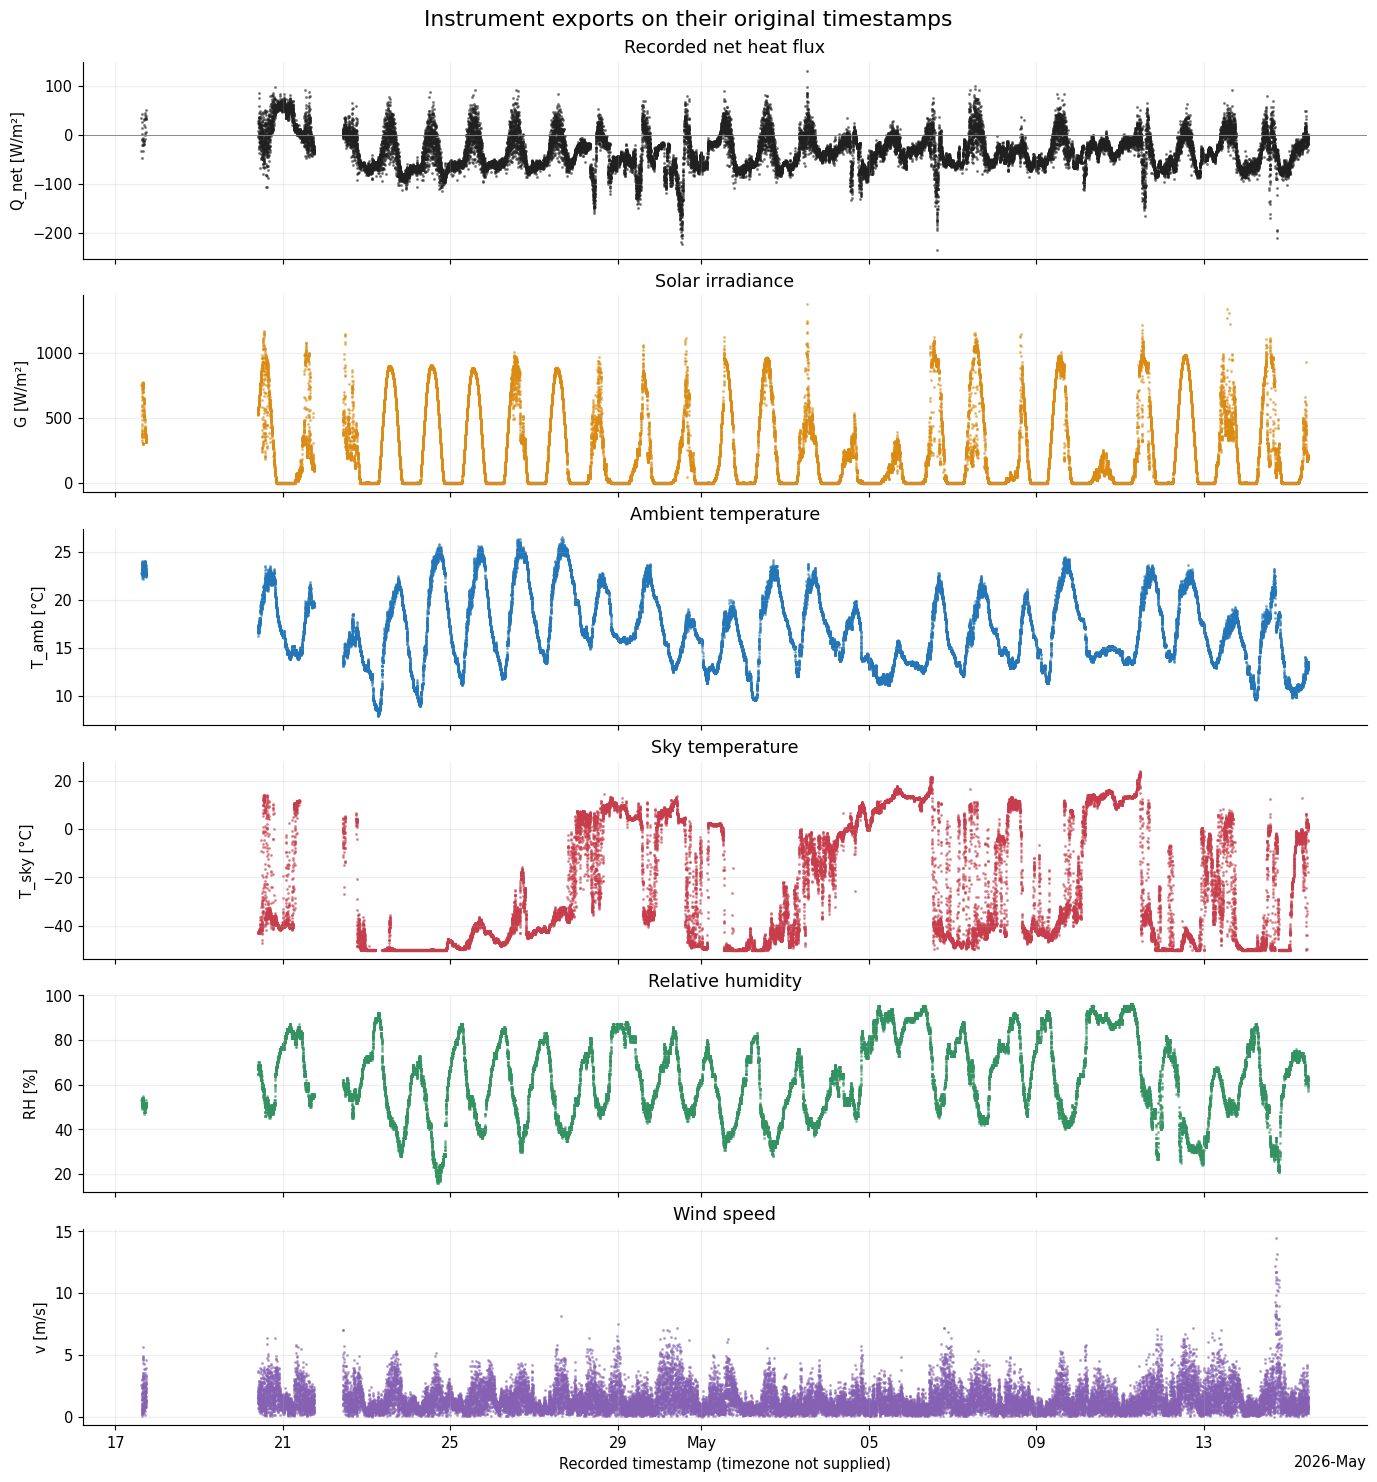

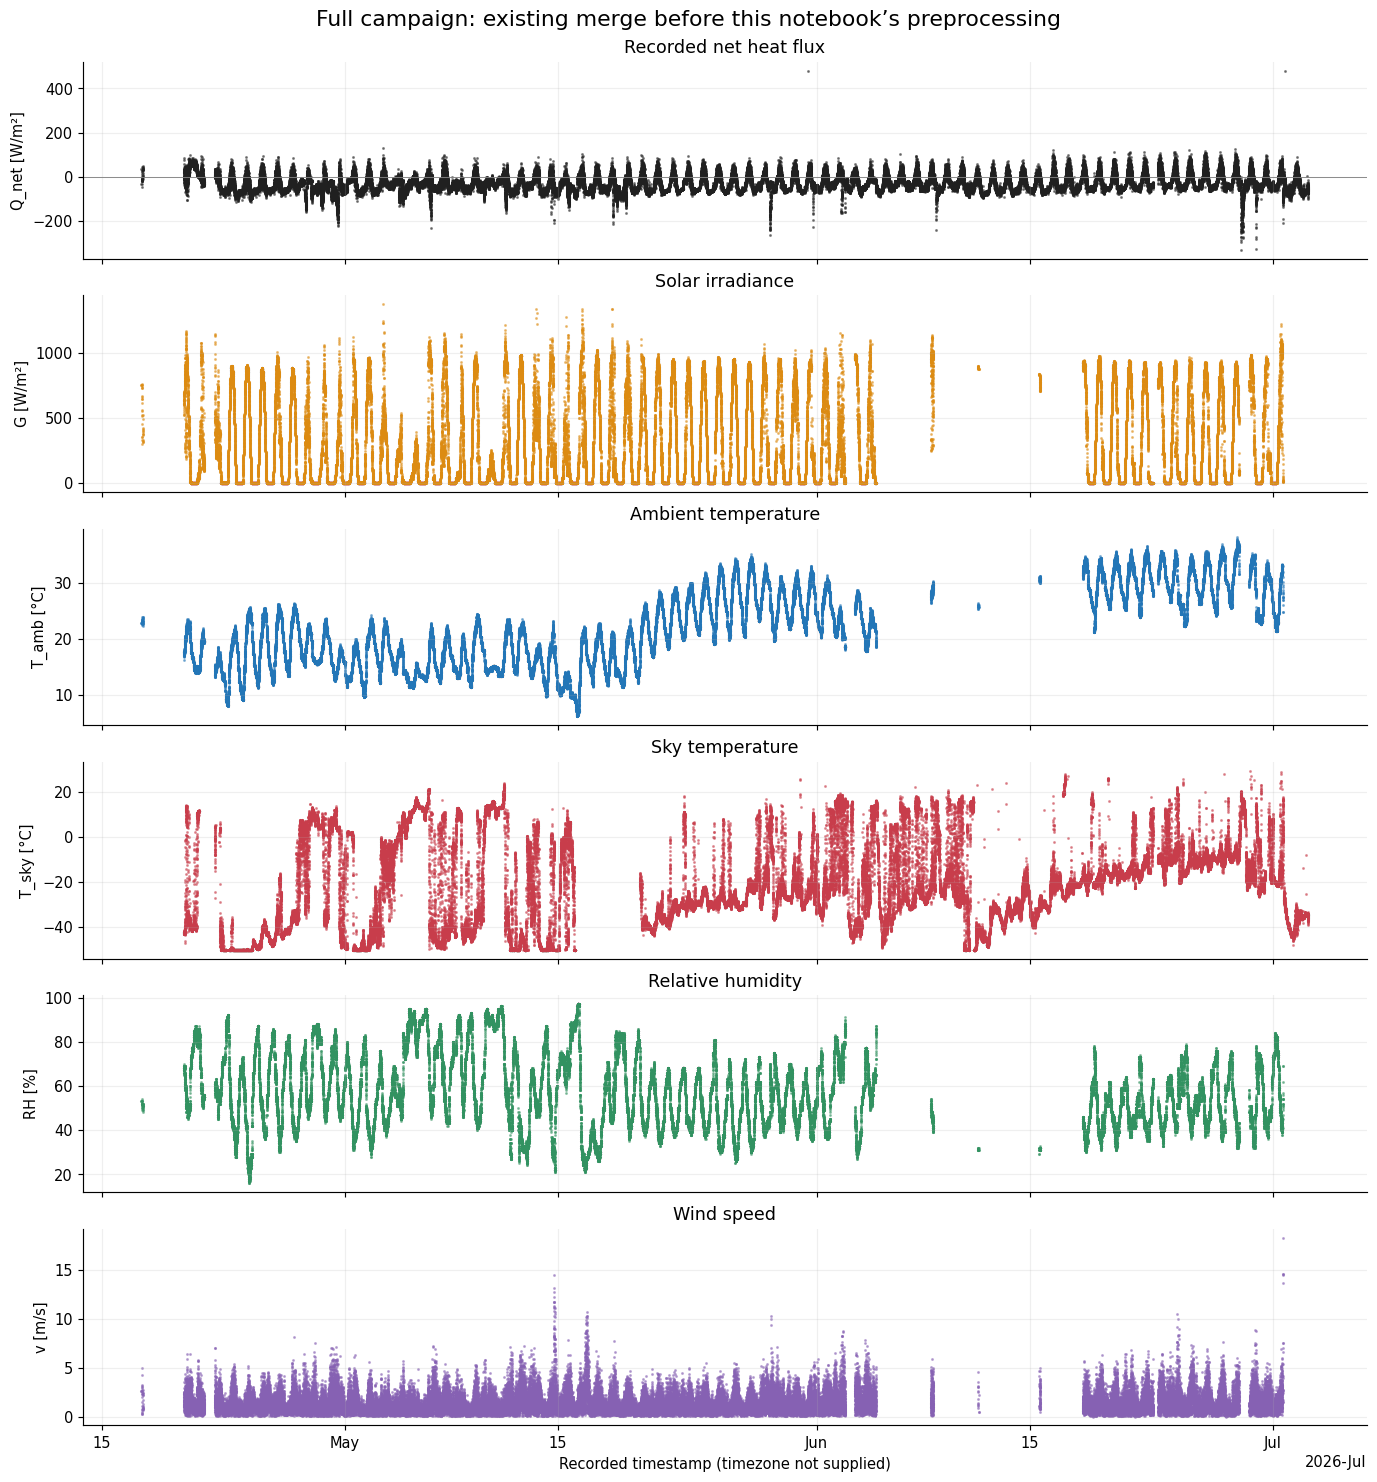

In [4]:
def date_axis(ax):
    locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

def plot_variables(series_by_name, title, points=False):
    fig, axes = plt.subplots(6, 1, figsize=(13, 14), sharex=True, layout='constrained')
    for ax, name in zip(axes, PLOT_ORDER):
        series = series_by_name[name]
        label, unit, colour = LABELS[name]
        if points:
            ax.scatter(series.index, series, s=1.2, alpha=0.45, color=colour, rasterized=True)
        else:
            ax.plot(series.index, series, linewidth=0.65, color=colour)
        ax.set(title=label, ylabel=unit)
        if name == TARGET:
            ax.axhline(0, color='grey', linewidth=0.6)
    date_axis(axes[-1])
    axes[-1].set_xlabel('Recorded timestamp (timezone not supplied)')
    fig.suptitle(title, fontsize=15)
    plt.show()
    plt.close(fig)

plot_variables(native_series, 'Instrument exports on their original timestamps', points=True)
plot_variables({name: full[name] for name in MODEL_COLS},
               'Full campaign: existing merge before this notebook’s preprocessing', points=True)

## 3. Synchronize without inventing observations

For each variable, calculate the mean of finite readings in the same fixed, left-closed,
left-labelled **three-minute** bins anchored at midnight. One or more readings per
variable per bin is required. This aligns intervals, not instantaneous measurements:
within-bin timing differences can remain, up to the bin width. Missing bins stay `NaN`.

Compare the freshly aligned native exports with the full table over their shared period.
Differences can arise from the earlier merge's assignment/averaging; the comparison is
a diagnostic, not proof of the unknown earlier merge. Then choose the configured scope
and remove bins missing **any of the six model variables**. A uniform underlying grid
with excluded intervals is expected; retained rows need not be consecutive in time.

No time interpolation or moving average is used. Aggregation alone averages readings
inside each bin. The latest audio asks to remove missing intervals, and additional
smoothing would alter the target and introduce overlap between adjacent samples.

In [5]:
def bin_series(series):
    resampler = series.resample(GRID, origin='start_day', closed='left', label='left')
    return resampler.mean(), resampler.count()

native_pairs = {name: bin_series(native_series[name]) for name in MODEL_COLS}
native_grid = pd.concat({name: pair[0] for name, pair in native_pairs.items()}, axis=1)
native_counts = pd.concat({name: pair[1] for name, pair in native_pairs.items()}, axis=1).fillna(0)
full_resampler = full[MODEL_COLS].resample(GRID, origin='start_day', closed='left', label='left')
full_grid = full_resampler.mean()
full_counts = full_resampler.count()

overlap_rows = []
for name in MODEL_COLS:
    common = pd.concat([native_grid[name].rename('Native'), full_grid[name].rename('Previous merge')],
                       axis=1).dropna()
    error = common['Previous merge'] - common['Native']
    overlap_rows.append({'Variable': name, 'Paired bins': len(common),
                         'Mean absolute difference': error.abs().mean(),
                         'Maximum absolute difference': error.abs().max()})
display(pd.DataFrame(overlap_rows).set_index('Variable'))

aligned = (full_grid if DATA_SCOPE == 'full_campaign' else native_grid).copy()
counts = (full_counts if DATA_SCOPE == 'full_campaign' else native_counts).copy()
complete = aligned[MODEL_COLS].notna().all(axis=1)
model_data = aligned.loc[complete, MODEL_COLS].copy()
rejected = aligned.index[~complete]
assert (counts.loc[complete, MODEL_COLS] >= 1).all().all()
assert np.isfinite(model_data.to_numpy()).all()
assert model_data.index.is_unique and model_data.index.is_monotonic_increasing
assert ((model_data.index - model_data.index.normalize()) % pd.Timedelta(GRID) == pd.Timedelta(0)).all()
assert len(model_data) > 100, 'Too few complete bins for meaningful validation.'

coverage = pd.DataFrame({'Observed bins': aligned.notna().sum(),
                         'Missing bins': aligned.isna().sum(),
                         'Coverage (%)': 100 * aligned.notna().mean()})
display(coverage.loc[PLOT_ORDER])
display(pd.Series({'Grid slots': len(aligned), 'Complete retained bins': len(model_data),
                   'Excluded incomplete bins': len(rejected), 'Interpolated bins': 0,
                   'First retained bin': model_data.index.min(),
                   'Last retained bin': model_data.index.max()}, name='Preparation').to_frame())

def missing_runs(mask):
    runs = []
    for _, segment in mask.groupby(mask.ne(mask.shift()).cumsum()):
        if segment.iloc[0]:
            runs.append({'Start': segment.index[0], 'End (exclusive)': segment.index[-1] + pd.Timedelta(GRID),
                         'Missing bins': len(segment), 'Hours': len(segment) * pd.Timedelta(GRID).total_seconds()/3600})
    return pd.DataFrame(runs, columns=['Start', 'End (exclusive)', 'Missing bins', 'Hours'])

gap_table = missing_runs(~complete).sort_values('Missing bins', ascending=False)
display(Markdown('**Largest excluded intervals**'))
display(gap_table.head(10).reset_index(drop=True))

,Paired bins,Mean absolute difference,Maximum absolute difference
Variable,,,
T_amb,11744,1.7780e-02,7.3333e-01
RH,11744,6.8673e-02,4.0000e+00
v,11744,7.0343e-02,3.8167e+00
G,11744,2.1720e+00,2.7200e+02
T_sky,11307,8.3849e-02,1.1733e+01
Q_net,11744,6.8333e-16,2.8422e-14


,Observed bins,Missing bins,Coverage (%)
Q_net,35029,1794,95.1280
G,27189,9634,73.8370
T_amb,27189,9634,73.8370
T_sky,32467,4356,88.1704
RH,27189,9634,73.8370
v,27189,9634,73.8370


,Preparation
Grid slots,36823
Complete retained bins,24628
Excluded incomplete bins,12195
Interpolated bins,0
First retained bin,2026-04-20 09:36:00
Last retained bin,2026-07-01 15:24:00


**Largest excluded intervals**

,Start,End (exclusive),Missing bins,Hours
0,2026-05-16 03:18:00,2026-05-20 09:03:00,2035,101.75
1,2026-06-11 15:33:00,2026-06-15 15:36:00,1921,96.05
2,2026-06-04 21:42:00,2026-06-08 12:03:00,1727,86.35
3,2026-06-08 16:15:00,2026-06-11 15:15:00,1420,71.00
4,2026-06-15 16:42:00,2026-06-18 11:39:00,1339,66.95
5,2026-04-17 14:51:00,2026-04-20 09:36:00,1335,66.75
6,2026-07-01 15:27:00,2026-07-03 08:00:00,811,40.55
7,2026-04-21 09:33:00,2026-04-22 10:15:00,494,24.70
8,2026-06-28 18:39:00,2026-06-29 10:36:00,319,15.95
9,2026-06-02 21:27:00,2026-06-03 12:18:00,297,14.85


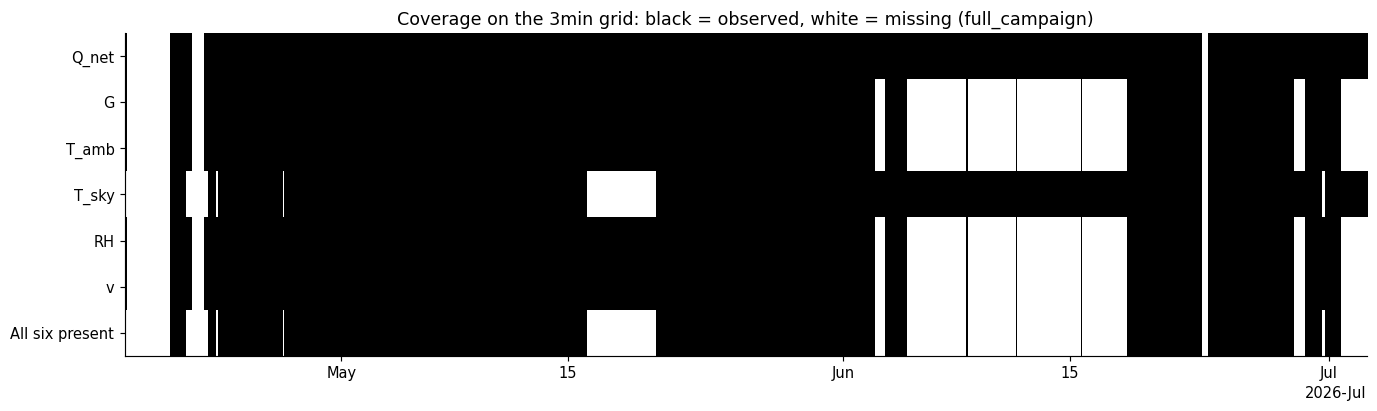

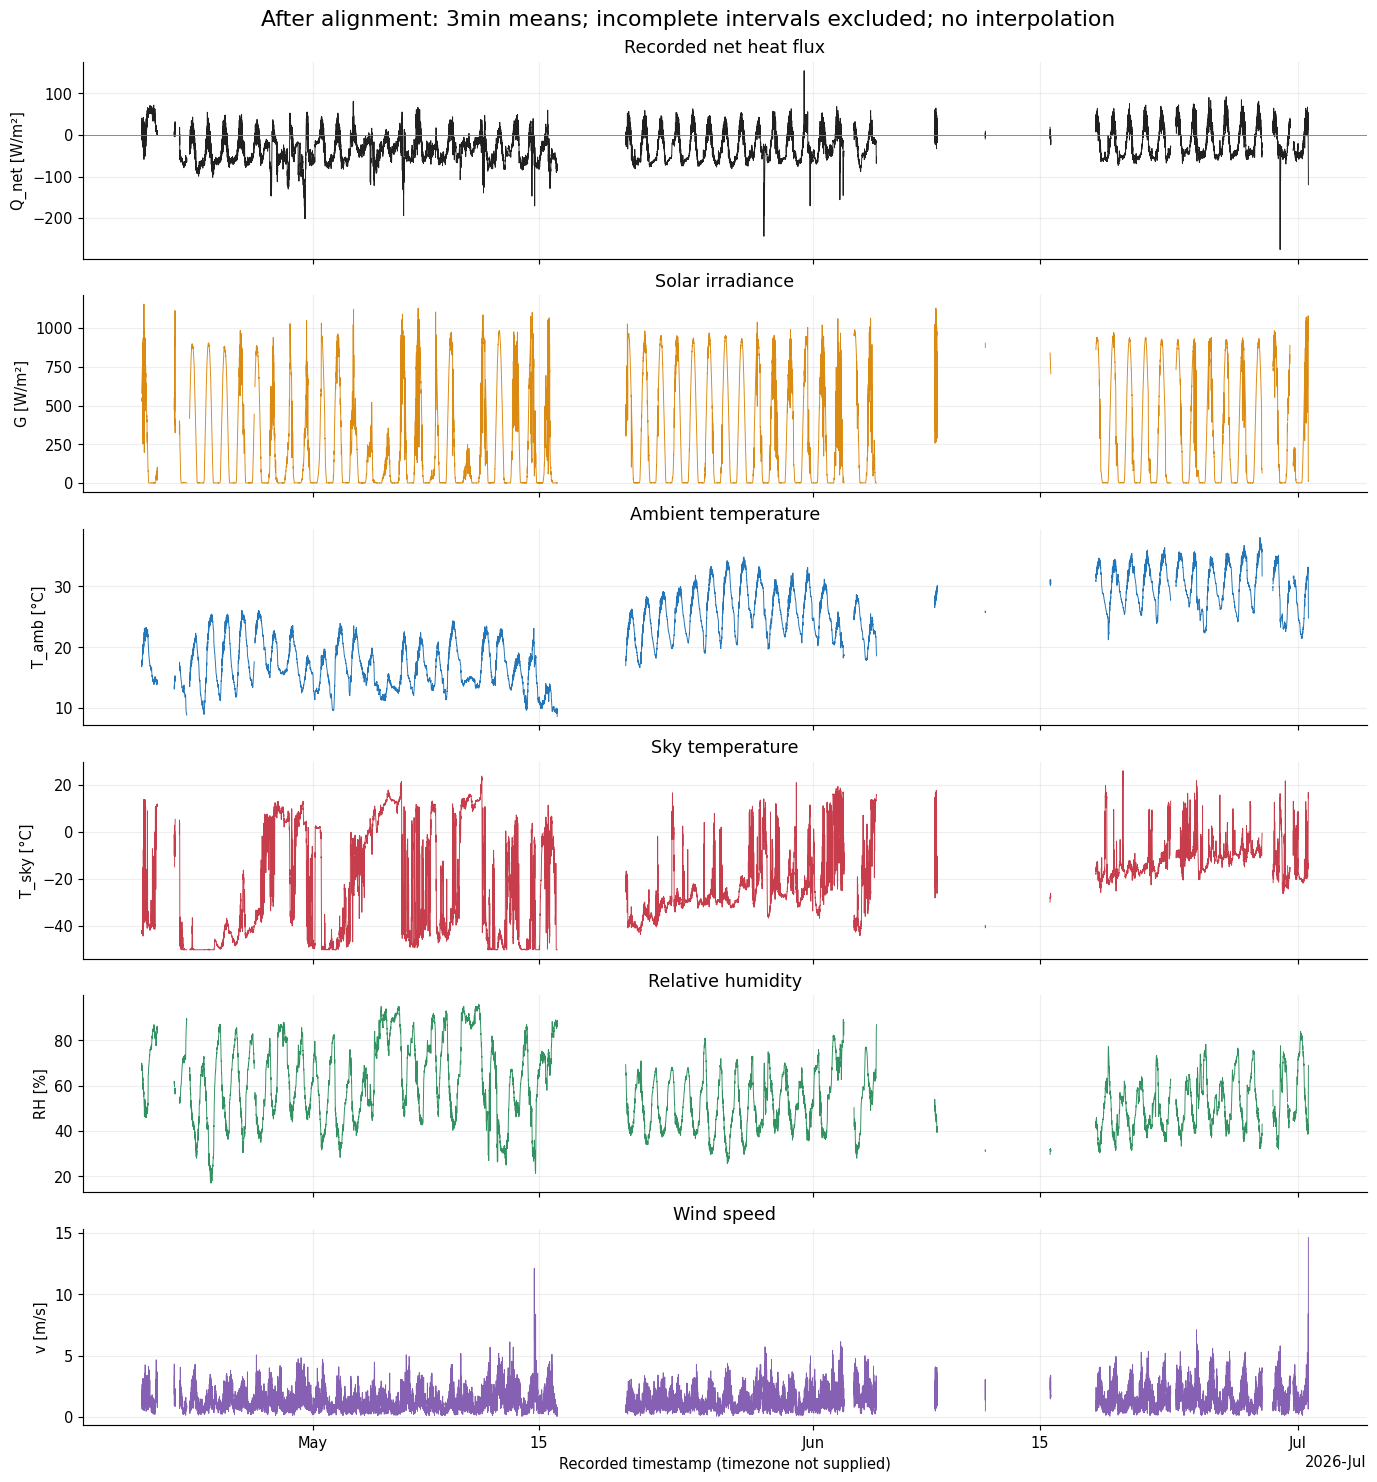

In [6]:
# Rows show per-variable availability before intersection; the last row is the model eligibility mask.
availability = np.vstack([aligned[PLOT_ORDER].notna().to_numpy().T, complete.to_numpy()])
fig, ax = plt.subplots(figsize=(13, 3.8), layout='constrained')
start_num = mdates.date2num(aligned.index[0])
end_num = mdates.date2num(aligned.index[-1] + pd.Timedelta(GRID))
ax.imshow(availability, aspect='auto', interpolation='nearest', cmap='Greys', vmin=0, vmax=1,
          extent=[start_num, end_num, len(PLOT_ORDER)+0.5, -0.5])
ax.set_yticks(range(7), [*PLOT_ORDER, 'All six present'])
ax.set_title(f'Coverage on the {GRID} grid: black = observed, white = missing ({DATA_SCOPE})')
ax.grid(False)
ax.xaxis_date()
date_axis(ax)
plt.show()
plt.close(fig)

# Restore missing grid positions for plotting only; never use dropna() to connect across outages.
plot_grid = model_data.reindex(aligned.index)
assert plot_grid.loc[~complete].isna().all().all()
plot_variables({name: plot_grid[name] for name in MODEL_COLS},
               f'After alignment: {GRID} means; incomplete intervals excluded; no interpolation')

### Individual time-series figures

These six full-size figures correspond to `Q_net_vs_time`, `G_vs_time`,
`T_amb_vs_time`, `T_sky_vs_time`, `RH_vs_time` and `v_vs_time` in the earlier
`figures_main_3` collection. They are regenerated from this notebook's selected
dataset on its three-minute grid. Missing intervals remain visible gaps, and the
recorded heat-flux sign is preserved. The coverage and combined six-variable
figures appear immediately above. Every figure is displayed and stored inline;
no separate PNG or PDF is written.

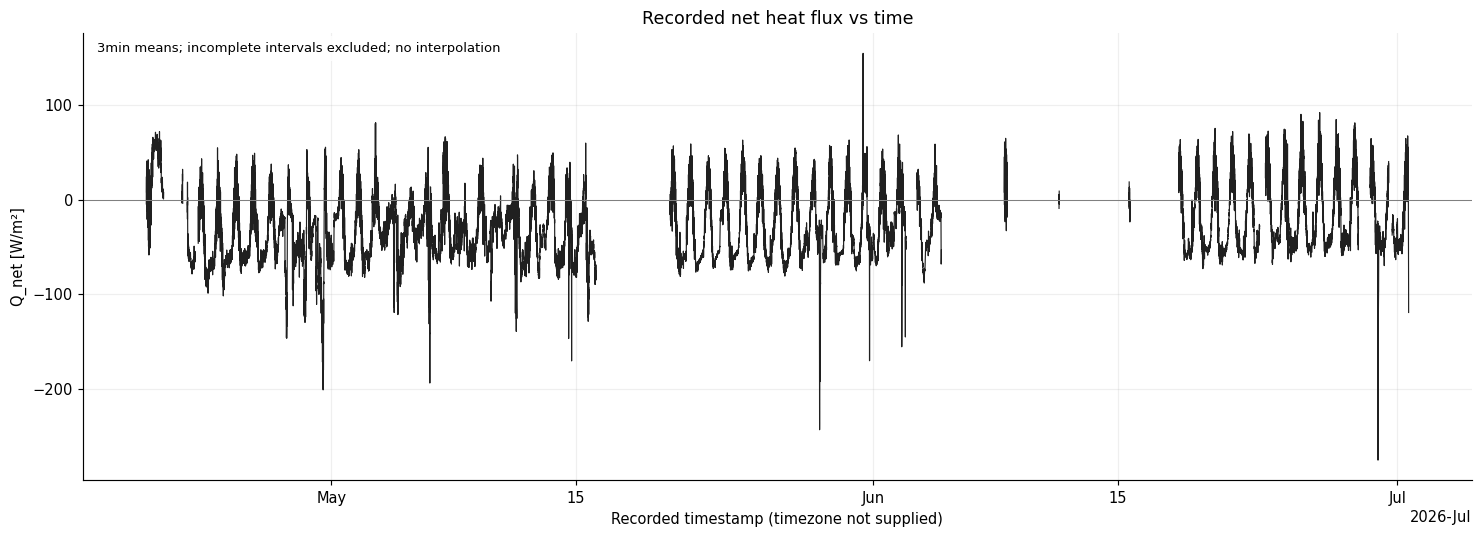

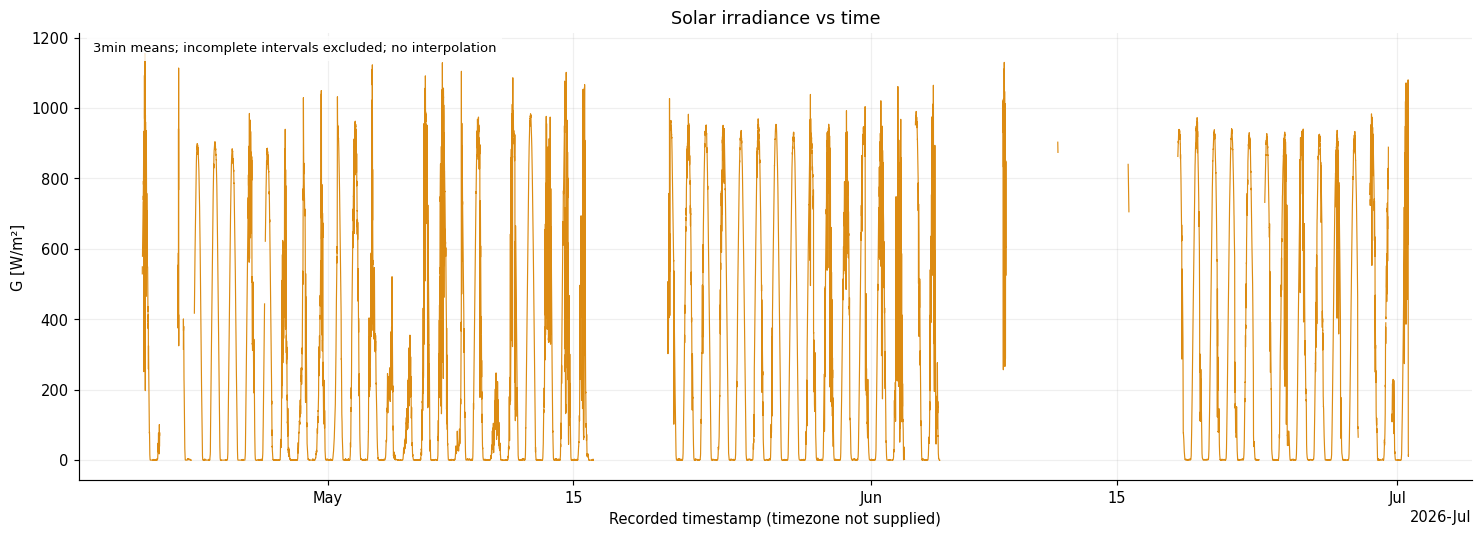

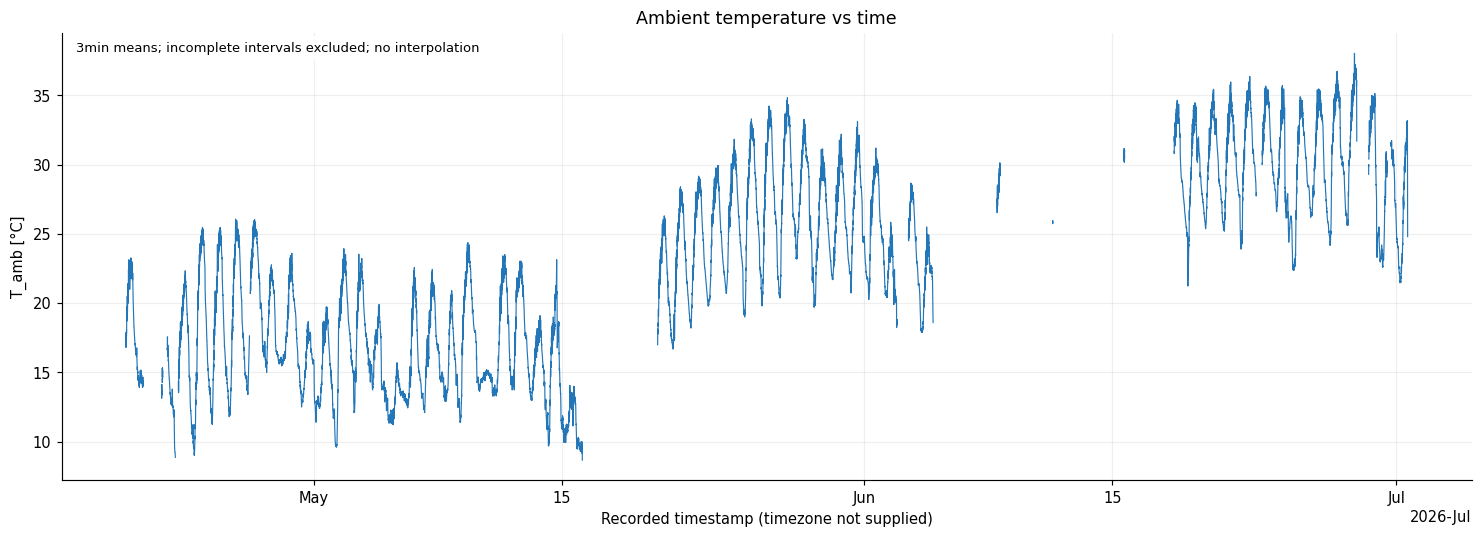

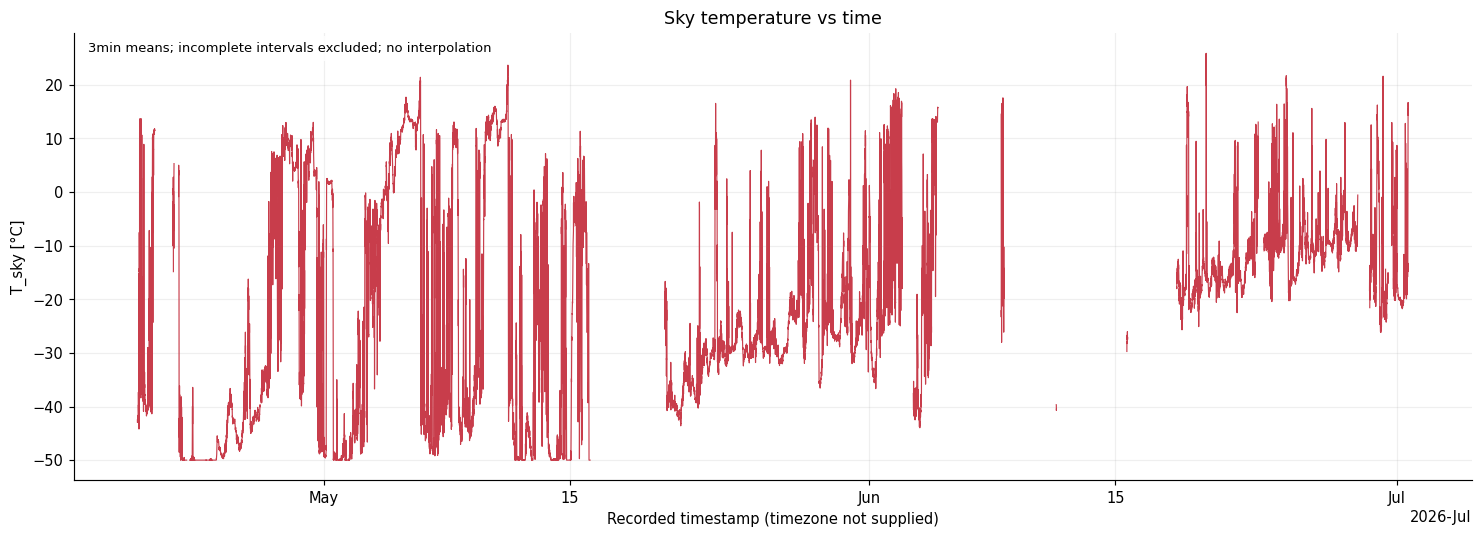

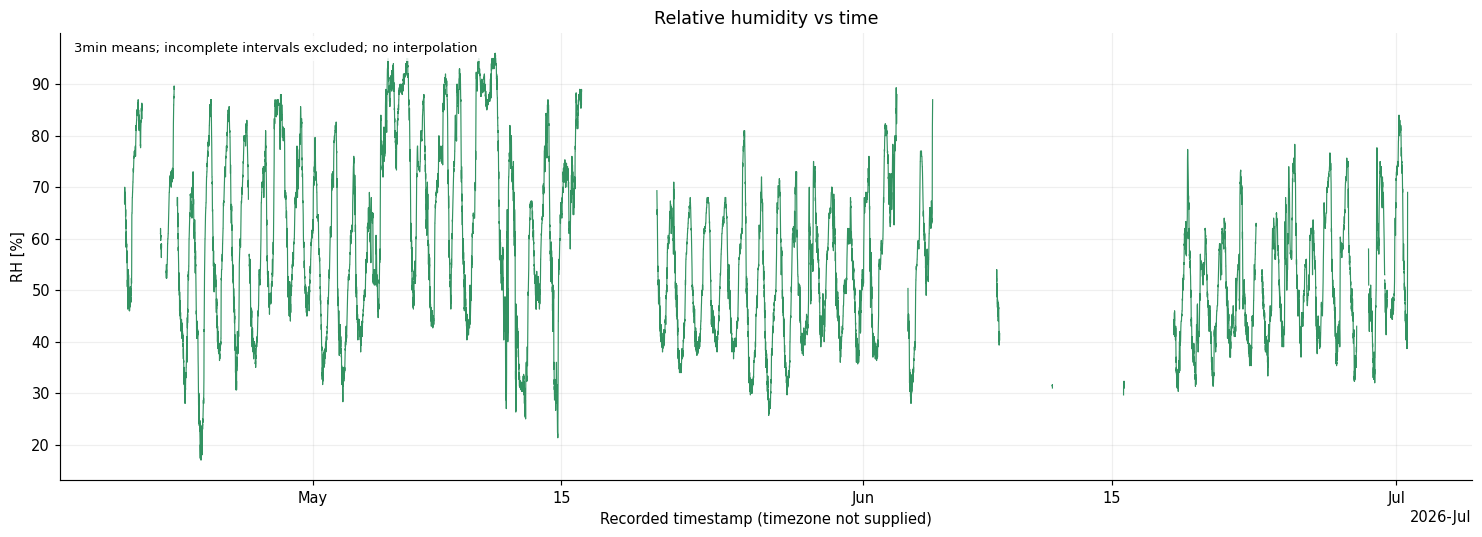

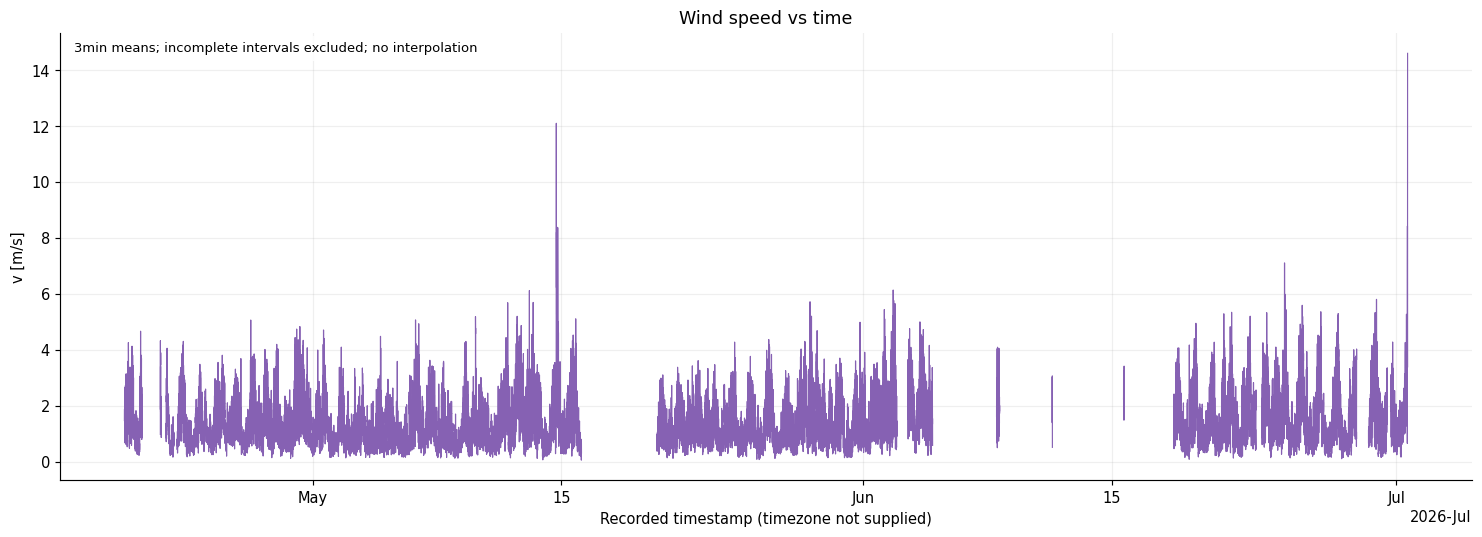

In [7]:
for name in PLOT_ORDER:
    title, unit, colour = LABELS[name]
    fig, ax = plt.subplots(figsize=(14, 5), layout='constrained')
    ax.plot(plot_grid.index, plot_grid[name], color=colour, linewidth=0.8)
    if name == TARGET:
        ax.axhline(0, color='grey', linewidth=0.7)
    ax.set(title=f'{title} vs time', ylabel=unit,
           xlabel='Recorded timestamp (timezone not supplied)')
    date_axis(ax)
    ax.text(0.01, 0.98, f'{GRID} means; incomplete intervals excluded; no interpolation',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85})
    plt.show()
    plt.close(fig)

### Compare acquisition and alignment on the same time window

The next plot contrasts input readings with bin means for a representative early
three-day window. Its title states whether those readings came from native exports
or the existing full merge. Missing processed bins remain gaps. This checks what the
alignment changed without averaging across instrument outages.

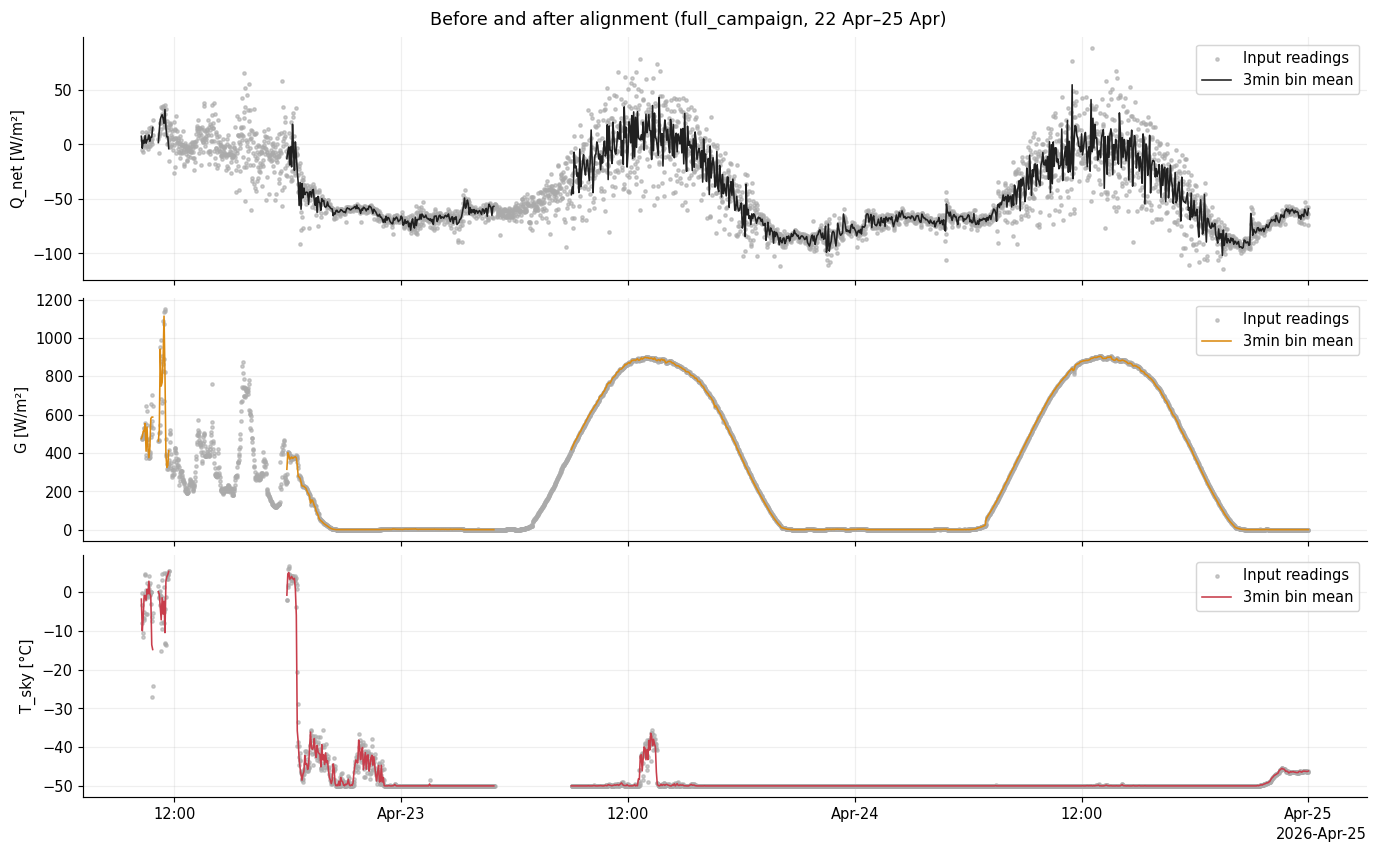

In [8]:
window_start = model_data.index.min().normalize() + pd.Timedelta('2D')
window_end = window_start + pd.Timedelta('3D')
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True, layout='constrained')
for ax, name in zip(axes, ['Q_net', 'G', 'T_sky']):
    before = full[name] if DATA_SCOPE == 'full_campaign' else native_series[name]
    before = before.loc[window_start:window_end]
    after = plot_grid.loc[window_start:window_end, name]
    ax.scatter(before.index, before, color='#aaaaaa', s=5, alpha=0.6, label='Input readings')
    ax.plot(after.index, after, color=LABELS[name][2], linewidth=1.1, label=f'{GRID} bin mean')
    ax.set_ylabel(LABELS[name][1])
    ax.legend(loc='upper right')
date_axis(axes[-1])
fig.suptitle(f'Before and after alignment ({DATA_SCOPE}, {window_start:%d %b}–{window_end:%d %b})')
plt.show()
plt.close(fig)

## 4. Data checks and descriptive relationships

,count,mean,std,min,1%,50%,99%,max
T_amb,24628.0,22.4152,6.7625,8.6667,9.9000,22.2500,35.1333,38.0333
RH,24628.0,57.4078,16.1968,17.0000,28.3333,55.6667,93.0000,96.0000
v,24628.0,1.4001,0.8744,0.0533,0.2367,1.2033,4.0858,14.6100
G,24628.0,280.1789,339.2231,0.0000,0.0000,83.3333,970.0000,1155.3333
T_sky,24628.0,-20.6829,19.2584,-50.0000,-50.0000,-20.8333,15.7577,25.8667
Q_net,24628.0,-28.9543,35.8122,-275.7414,-100.3802,-36.0811,57.2158,154.7769


,Count
Sky values exactly -50 °C (input readings),4588
RH outside 0–100% (input readings),0
Negative wind speed (input readings),0
Negative solar irradiance (input readings),0
"Retained bins with |Q_net| > 100 W/m² (review, not automatic rejection)",252


**Ten largest recorded absolute target values after binning**

,T_amb,RH,v,G,T_sky,Q_net
timestamp,,,,,,
2026-06-29 21:21:00,27.5667,56.6667,3.3800,4.6667,14.0000,-275.7414
2026-05-28 22:24:00,26.4000,62.6667,2.0800,0.6667,-2.7667,-243.6072
2026-05-28 22:27:00,26.2000,63.6667,2.2467,3.3333,-5.1333,-237.1542
2026-05-28 22:21:00,26.7000,62.0000,1.5433,0.0000,7.3667,-211.0505
2026-04-30 12:33:00,14.6333,54.3333,2.7733,289.3333,3.9000,-201.4164
2026-04-30 12:39:00,14.8667,55.3333,3.2933,300.0000,3.6667,-199.7544
2026-06-29 21:18:00,27.7667,54.3333,2.5100,1.0000,16.2333,-198.0138
2026-05-06 15:06:00,20.5000,51.6667,2.9067,905.0000,-41.6333,-194.1540
2026-05-28 22:30:00,26.0000,64.3333,1.0900,4.6667,-7.6000,-194.0084


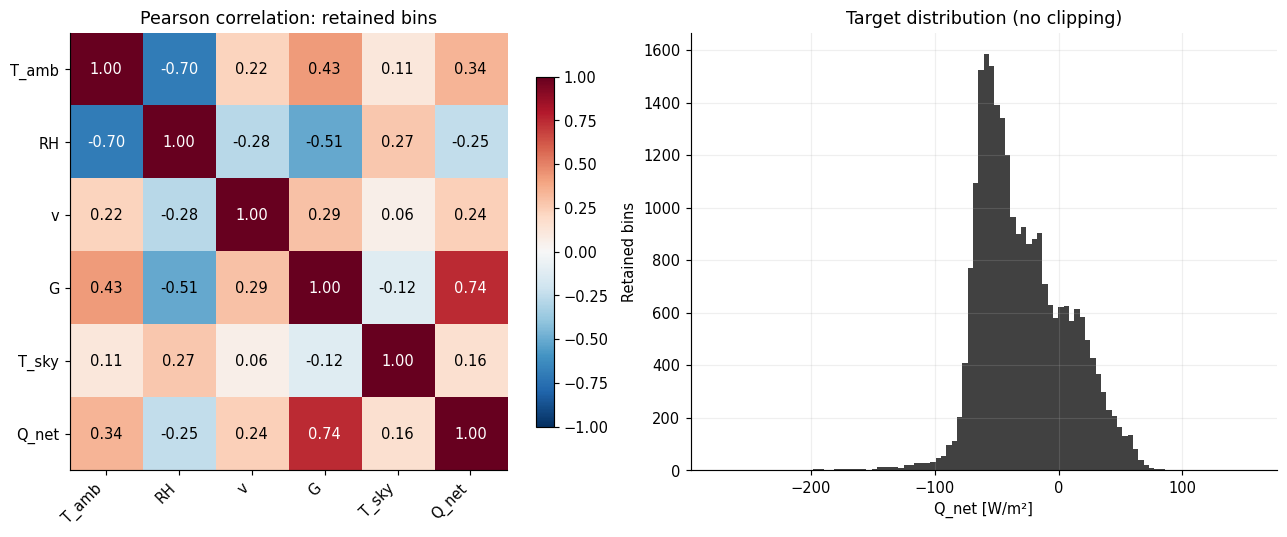

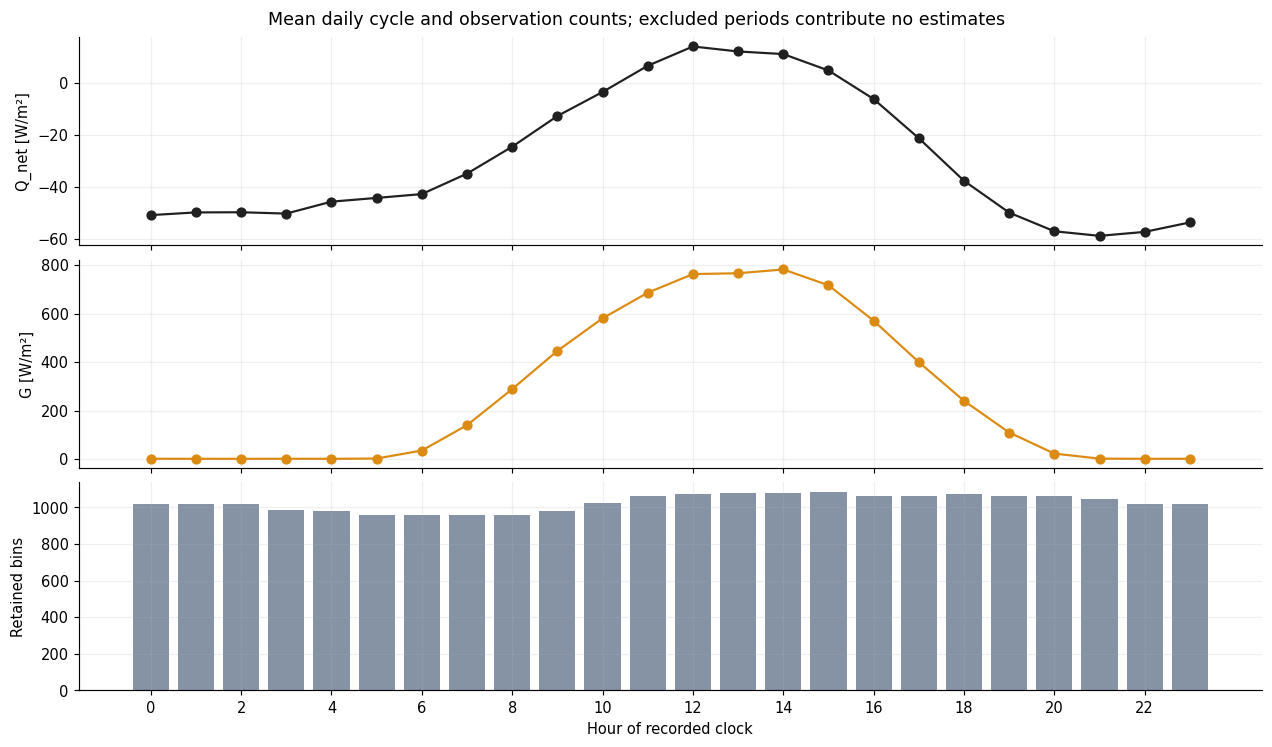

In [9]:
display(model_data.describe(percentiles=[0.01, 0.5, 0.99]).T)
input_for_checks = full[MODEL_COLS] if DATA_SCOPE == 'full_campaign' else native_full[MODEL_COLS]
flags = pd.Series({
    'Sky values exactly -50 °C (input readings)': int(input_for_checks['T_sky'].eq(-50).sum()),
    'RH outside 0–100% (input readings)': int((input_for_checks['RH'].lt(0) | input_for_checks['RH'].gt(100)).sum()),
    'Negative wind speed (input readings)': int(input_for_checks['v'].lt(0).sum()),
    'Negative solar irradiance (input readings)': int(input_for_checks['G'].lt(0).sum()),
    'Retained bins with |Q_net| > 100 W/m² (review, not automatic rejection)': int(model_data[TARGET].abs().gt(100).sum()),
}, name='Count')
display(flags.to_frame())
display(Markdown('**Ten largest recorded absolute target values after binning**'))
display(model_data.loc[model_data[TARGET].abs().nlargest(10).index])

correlation = model_data[MODEL_COLS].corr()
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout='constrained')
im = axes[0].imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(6), MODEL_COLS, rotation=45, ha='right')
axes[0].set_yticks(range(6), MODEL_COLS)
axes[0].grid(False)
for row in range(6):
    for col in range(6):
        value = correlation.iloc[row, col]
        axes[0].text(col, row, f'{value:.2f}', ha='center', va='center',
                     color='white' if abs(value) > 0.65 else 'black')
axes[0].set_title('Pearson correlation: retained bins')
fig.colorbar(im, ax=axes[0], shrink=0.8)
axes[1].hist(model_data[TARGET], bins=100, color=LABELS[TARGET][2], alpha=0.85)
axes[1].set(xlabel=LABELS[TARGET][1], ylabel='Retained bins', title='Target distribution (no clipping)')
plt.show()
plt.close(fig)

hour_groups = model_data.groupby(model_data.index.hour)
hourly_means = hour_groups[[TARGET, 'G']].mean()
hourly_counts = hour_groups.size()
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True, layout='constrained')
for ax, name in zip(axes[:2], [TARGET, 'G']):
    ax.plot(hourly_means.index, hourly_means[name], marker='o', color=LABELS[name][2])
    ax.set_ylabel(LABELS[name][1])
axes[2].bar(hourly_counts.index, hourly_counts, color='#8693a5')
axes[2].set(xlabel='Hour of recorded clock', ylabel='Retained bins', xticks=range(0, 24, 2))
fig.suptitle('Mean daily cycle and observation counts; excluded periods contribute no estimates')
plt.show()
plt.close(fig)

### Mean daily cycle: net heat flux and solar irradiance

This reproduces the two-axis layout of `02_mean_daily_cycle` using only the retained
observations. Read heat flux against the left axis and solar irradiance against the
right axis; the heights of the two curves are not directly comparable. The separate
panels and observation counts above provide the same information without dual axes.

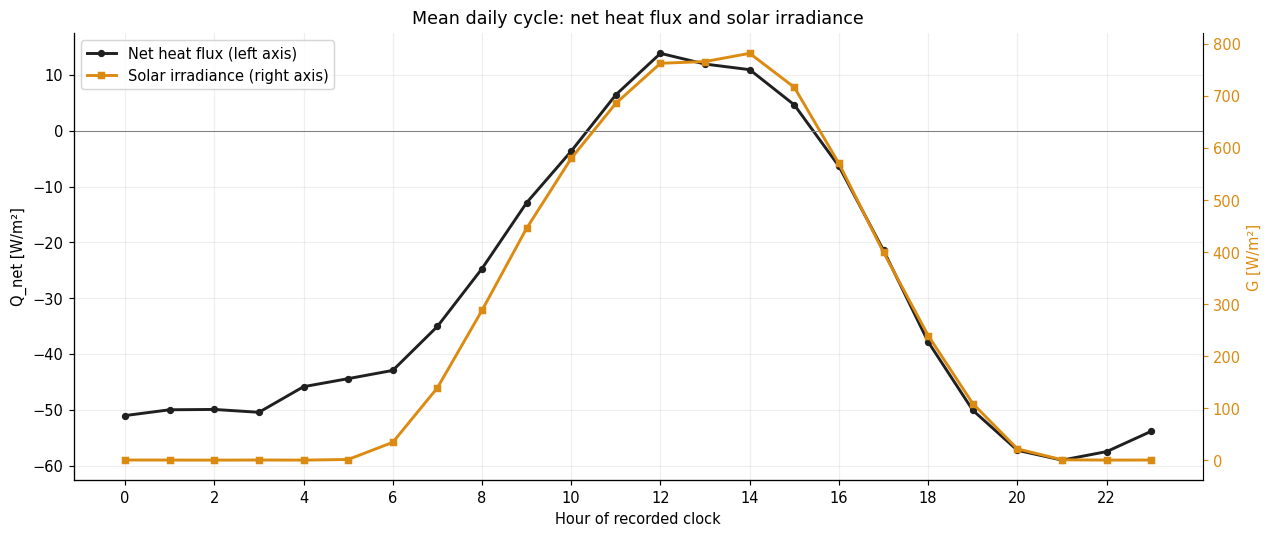

In [10]:
daily_cycle = model_data.groupby(model_data.index.hour)[[TARGET, 'G']].mean()
fig, flux_axis = plt.subplots(figsize=(12, 5), layout='constrained')
solar_axis = flux_axis.twinx()
flux_line, = flux_axis.plot(daily_cycle.index, daily_cycle[TARGET], marker='o',
                            linewidth=2, markersize=4, color=LABELS[TARGET][2],
                            label='Net heat flux (left axis)')
solar_line, = solar_axis.plot(daily_cycle.index, daily_cycle['G'], marker='s',
                              linewidth=2, markersize=4, color=LABELS['G'][2],
                              label='Solar irradiance (right axis)')
flux_axis.axhline(0, color='grey', linewidth=0.7)
flux_axis.set(xlabel='Hour of recorded clock', ylabel=LABELS[TARGET][1],
              xticks=range(0, 24, 2), title='Mean daily cycle: net heat flux and solar irradiance')
solar_axis.set_ylabel(LABELS['G'][1], color=LABELS['G'][2])
solar_axis.tick_params(axis='y', colors=LABELS['G'][2])
solar_axis.spines['right'].set_visible(True)
solar_axis.grid(False)
flux_axis.legend(handles=[flux_line, solar_line], loc='upper left')
plt.show()
plt.close(fig)

### Standalone correlation heatmap

This is the full-size counterpart of `03_correlation_heatmap`. It uses the same
retained-bin Pearson correlations as the diagnostic panel above. Correlations are
descriptive associations, not causal effects or measures of prediction accuracy.

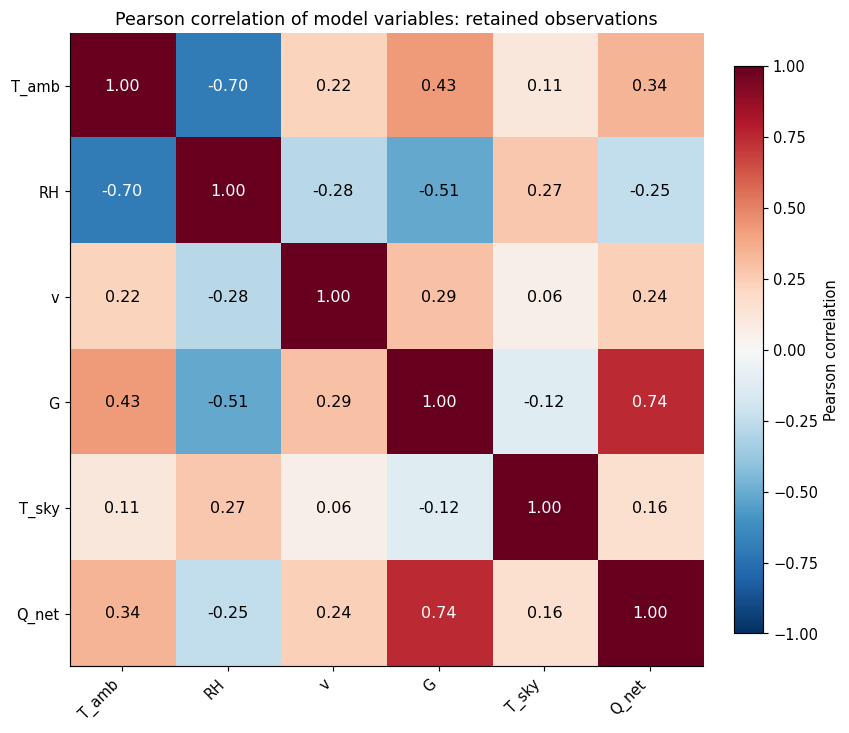

In [11]:
standalone_correlation = model_data[MODEL_COLS].corr()
fig, ax = plt.subplots(figsize=(8, 7), layout='constrained')
colour_map = ax.imshow(standalone_correlation, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(MODEL_COLS)), MODEL_COLS, rotation=45, ha='right')
ax.set_yticks(range(len(MODEL_COLS)), MODEL_COLS)
for row in range(len(MODEL_COLS)):
    for column in range(len(MODEL_COLS)):
        value = standalone_correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=11,
                color='white' if abs(value) > 0.65 else 'black')
ax.set_title('Pearson correlation of model variables: retained observations')
ax.grid(False)
fig.colorbar(colour_map, ax=ax, shrink=0.85, label='Pearson correlation')
plt.show()
plt.close(fig)

## 5. Fixed training and validation splits

,Training bins,Validation bins,Unused gap bins,Training first,Training last,Validation first,Validation last
Evaluation,,,,,,,
Random 80/20,19702,4926,0,2026-04-20 09:36:00,2026-07-01 15:21:00,2026-04-20 10:36:00,2026-07-01 15:24:00
Chronological holdout,19222,4926,480,2026-04-20 09:36:00,2026-06-19 04:24:00,2026-06-20 04:27:00,2026-07-01 15:24:00


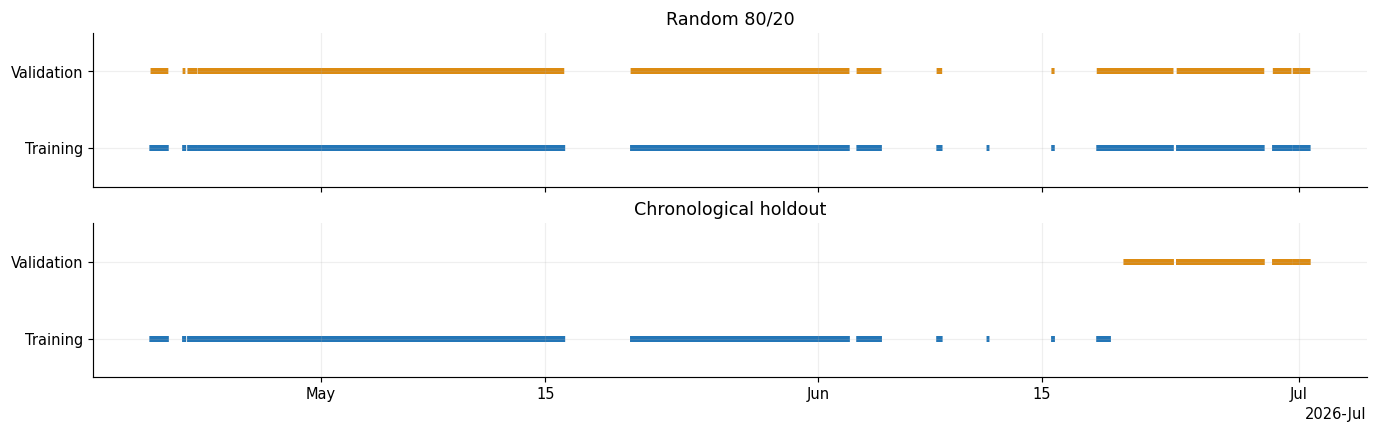

In [12]:
X = model_data[FEATURES]
y = model_data[TARGET]
positions = np.arange(len(model_data))
random_train, random_valid = train_test_split(positions, test_size=VALIDATION_FRACTION,
                                             random_state=SEED, shuffle=True)
cut = int(np.floor((1 - VALIDATION_FRACTION) * len(model_data)))
chrono_valid = positions[cut:]
chronological_start = model_data.index[cut]
chrono_train = positions[model_data.index < chronological_start - CHRONOLOGICAL_GAP]
splits = {'Random 80/20': (np.sort(random_train), np.sort(random_valid)),
          'Chronological holdout': (chrono_train, chrono_valid)}
split_rows = []
for name, (train, valid) in splits.items():
    assert len(train) > 100 and len(valid) > 20
    assert np.intersect1d(train, valid).size == 0
    split_rows.append({'Evaluation': name, 'Training bins': len(train), 'Validation bins': len(valid),
                       'Unused gap bins': len(model_data)-len(train)-len(valid),
                       'Training first': X.index[train].min(), 'Training last': X.index[train].max(),
                       'Validation first': X.index[valid].min(), 'Validation last': X.index[valid].max()})
assert X.index[chrono_train].max() < chronological_start - CHRONOLOGICAL_GAP
display(pd.DataFrame(split_rows).set_index('Evaluation'))

fig, axes = plt.subplots(2, 1, figsize=(13, 4), sharex=True, layout='constrained')
for ax, (name, (train, valid)) in zip(axes, splits.items()):
    ax.scatter(X.index[train], np.zeros(len(train)), marker='|', s=18, label='Training', color='#2376b7')
    ax.scatter(X.index[valid], np.ones(len(valid)), marker='|', s=18, label='Validation', color='#dc8b12')
    ax.set(yticks=[0, 1], yticklabels=['Training', 'Validation'], title=name, ylim=(-0.5, 1.5))
date_axis(axes[-1])
plt.show()
plt.close(fig)

## 6. Train a basic Random Forest and evaluate it

Use 100 trees with the standard untuned scikit-learn settings (`max_depth=None`,
`min_samples_leaf=1`, `max_features=1.0`, bootstrap sampling). Fix only the random seed
and use two CPU workers. A training-mean predictor provides a simple reference using
exactly the same training/validation indices.

RMSE penalizes large errors more strongly than MAE. R² is measured against variation
in the validation observations and can be negative. Training scores are shown to expose
overfitting, not presented as evidence of generalization. The presentation's Sample 1
MLP scores are not acceptance thresholds for this different campaign and model.

In [13]:
def regression_metrics(observed, predicted):
    return {'RMSE (W/m²)': np.sqrt(mean_squared_error(observed, predicted)),
            'MAE (W/m²)': mean_absolute_error(observed, predicted),
            'R²': r2_score(observed, predicted),
            'Bias (prediction − measurement)': float(np.mean(np.asarray(predicted) - np.asarray(observed)))}

fitted_models, predictions, metric_rows = {}, {}, []
for name, (train, valid) in splits.items():
    pipeline = Pipeline([
        ('scale', MinMaxScaler()),
        ('forest', RandomForestRegressor(n_estimators=100, max_depth=None,
                                         min_samples_leaf=1, max_features=1.0,
                                         bootstrap=True, random_state=SEED, n_jobs=2)),
    ])
    pipeline.fit(X.iloc[train], y.iloc[train])
    predicted = pipeline.predict(X.iloc[valid])
    baseline = DummyRegressor(strategy='mean').fit(X.iloc[train], y.iloc[train])
    baseline_predicted = baseline.predict(X.iloc[valid])
    assert np.isfinite(predicted).all()
    scaler = pipeline.named_steps['scale']
    assert np.allclose(scaler.data_min_, X.iloc[train].min())
    assert np.allclose(scaler.data_max_, X.iloc[train].max())
    fitted_models[name] = pipeline
    predictions[name] = pd.DataFrame({'Measured': y.iloc[valid], 'Predicted': predicted,
                                      'Training-mean baseline': baseline_predicted}, index=y.iloc[valid].index)
    predictions[name]['Residual (prediction − measurement)'] = predicted - y.iloc[valid]
    for model_name, partition, observed, estimate in [
        ('Random Forest', 'Validation', y.iloc[valid], predicted),
        ('Training-mean baseline', 'Validation', y.iloc[valid], baseline_predicted),
        ('Random Forest', 'Training', y.iloc[train], pipeline.predict(X.iloc[train])),
    ]:
        metric_rows.append({'Evaluation': name, 'Model': model_name, 'Partition': partition,
                            'N': len(observed), **regression_metrics(observed, estimate)})

metrics = pd.DataFrame(metric_rows)
display(Markdown('**Held-out results (the actual performance estimates)**'))
display(metrics.loc[metrics.Partition.eq('Validation')].set_index(['Evaluation', 'Model']).drop(columns='Partition').round(4))
display(Markdown('**Training results (overfitting diagnostic only)**'))
display(metrics.loc[metrics.Partition.eq('Training')].set_index('Evaluation').drop(columns=['Model', 'Partition']).round(4))

**Held-out results (the actual performance estimates)**

N  RMSE (W/m²)  MAE (W/m²)  \
Evaluation            Model                                                   
Random 80/20          Random Forest           4926      12.3938      7.2246   
                      Training-mean baseline  4926      35.6733     29.1944   
Chronological holdout Random Forest           4926      39.6405     19.1373   
                      Training-mean baseline  4926      39.9299     30.5904   

                                                  R²  \
Evaluation            Model                            
Random 80/20          Random Forest           0.8792   
                      Training-mean baseline -0.0006   
Chronological holdout Random Forest          -0.1490   
                      Training-mean baseline -0.1659   

                                              Bias (prediction − measurement)  
Evaluation            Model                                                    
Random 80/20          Random Forest                                   -0.0058  
                      Training-mean baseline                          -0.8592  
Chronological holdout Random Forest                                  -13.8469  
                      Training-mean baseline                         -15.0618

**Training results (overfitting diagnostic only)**

,N,RMSE (W/m²),MAE (W/m²),R²,Bias (prediction − measurement)
Evaluation,,,,,
Random 80/20,19702,4.8589,2.6683,0.9816,-0.0121
Chronological holdout,19222,4.8519,2.6643,0.9807,0.0135


### Measured validation values versus predictions

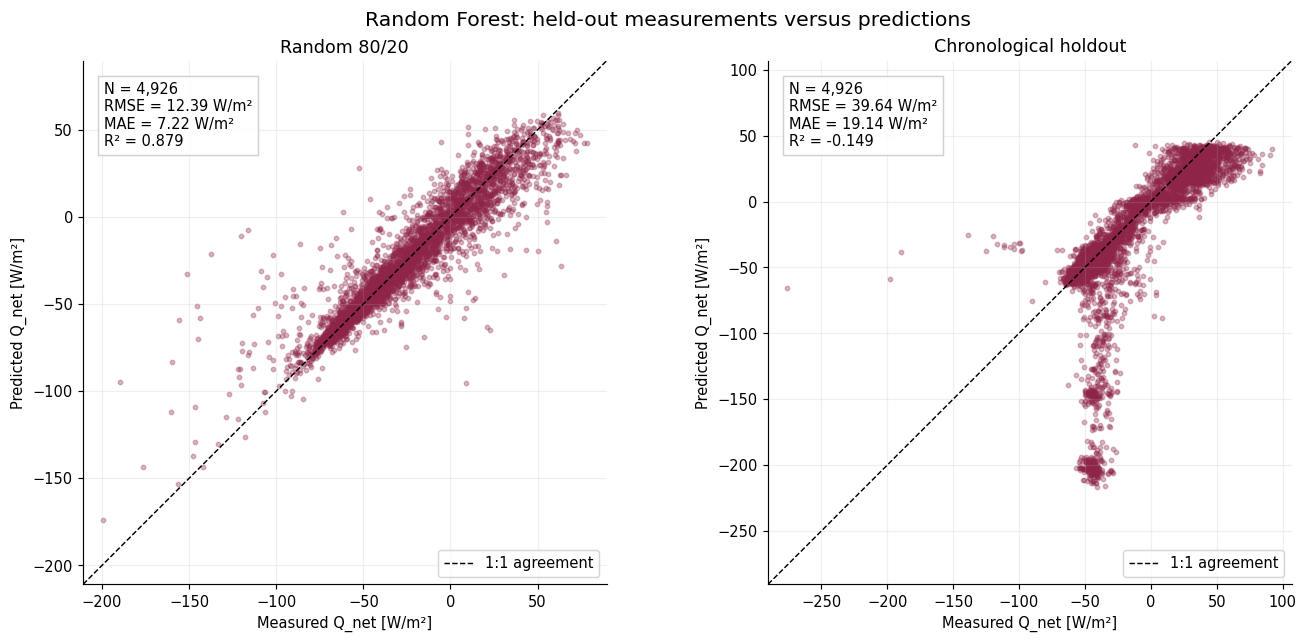

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), layout='constrained')
for ax, (name, result) in zip(axes, predictions.items()):
    ax.scatter(result['Measured'], result['Predicted'], s=9, alpha=0.32, color='#8e2548', rasterized=True)
    lower = result[['Measured', 'Predicted']].min().min()
    upper = result[['Measured', 'Predicted']].max().max()
    padding = 0.04 * max(upper-lower, 1)
    bounds = (lower-padding, upper+padding)
    ax.plot(bounds, bounds, '--', color='black', linewidth=1, label='1:1 agreement')
    ax.set(xlim=bounds, ylim=bounds, xlabel='Measured Q_net [W/m²]',
           ylabel='Predicted Q_net [W/m²]', title=name)
    ax.set_aspect('equal', adjustable='box')
    values = regression_metrics(result['Measured'], result['Predicted'])
    annotation = (f"N = {len(result):,}\nRMSE = {values['RMSE (W/m²)']:.2f} W/m²\n"
                  f"MAE = {values['MAE (W/m²)']:.2f} W/m²\nR² = {values['R²']:.3f}")
    ax.text(0.04, 0.96, annotation, transform=ax.transAxes, va='top',
            bbox={'facecolor': 'white', 'alpha': 0.9, 'edgecolor': '#cccccc'})
    ax.legend(loc='lower right')
fig.suptitle('Random Forest: held-out measurements versus predictions', fontsize=14)
plt.show()
plt.close(fig)

## 7. Check errors and reliance on the inputs


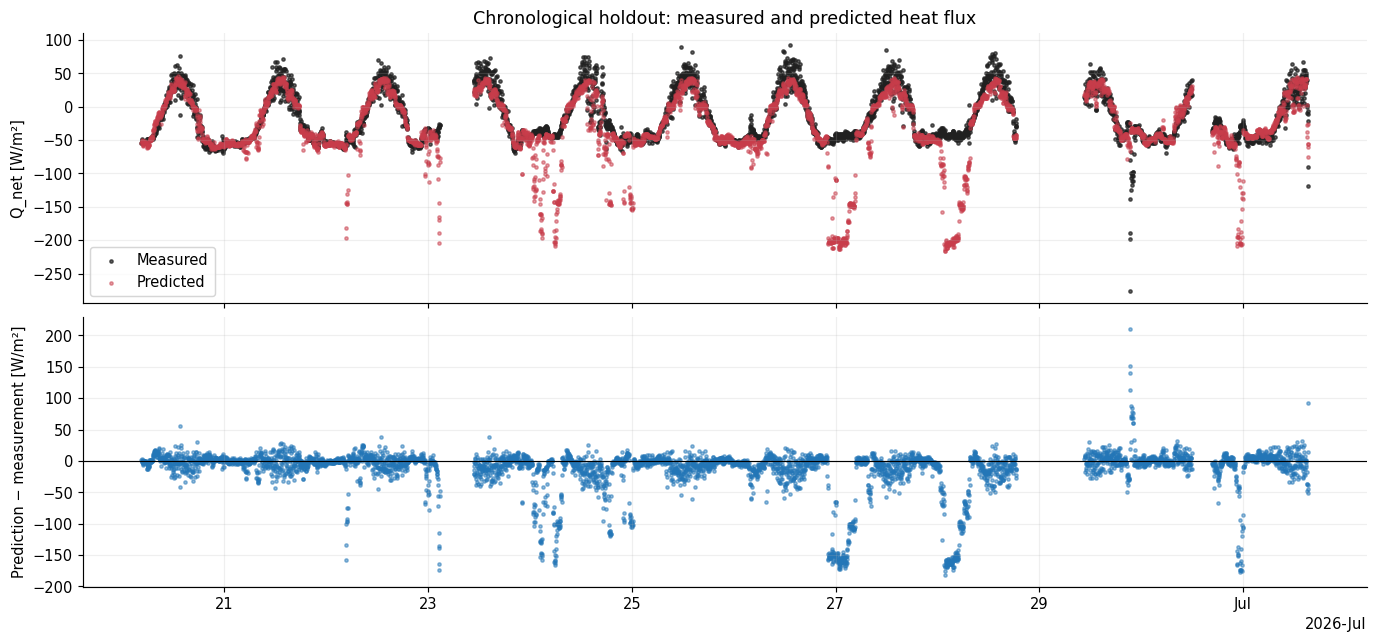

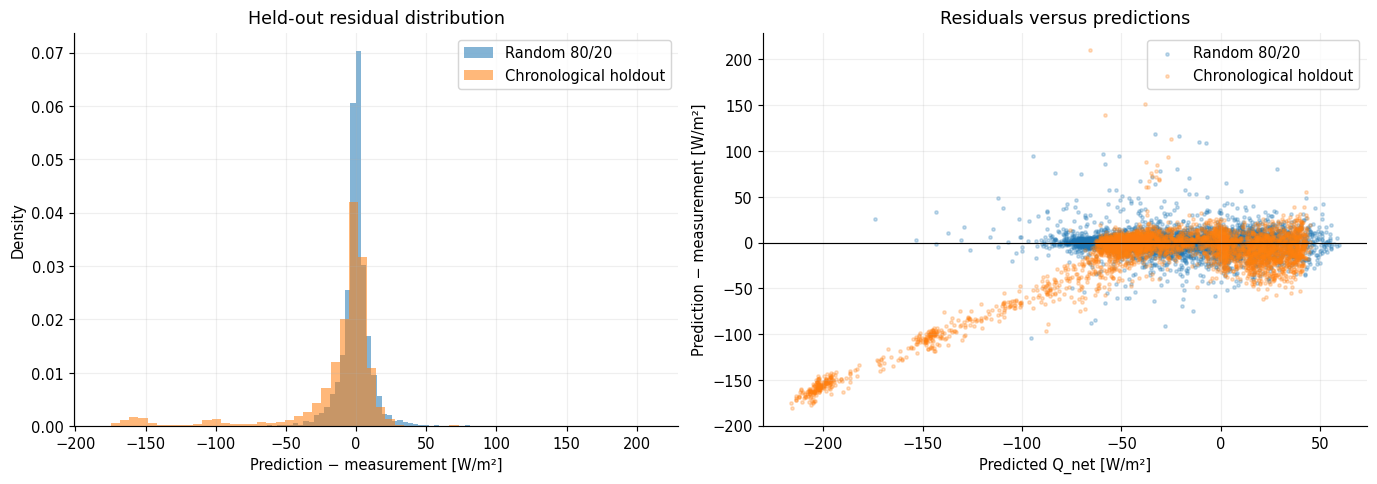

,RMSE increase (W/m²),Shuffle SD (W/m²)
Feature,,
T_sky,-0.5445,0.0764
RH,0.6136,0.6827
v,0.8128,0.0268
T_amb,15.2707,0.2736
G,17.1444,0.2318


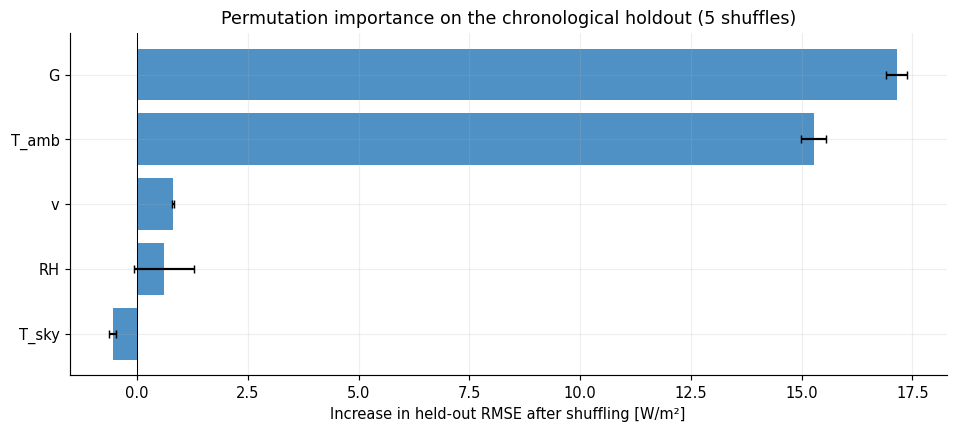

**Input-range shift in the later-period holdout**

,Train min,Train max,Validation min,Validation max,Validation outside training range (%)
T_amb,8.667,34.833,21.467,38.033,7.694
RH,17.000,96.000,31.333,84.000,0.000
v,0.053,12.107,0.103,14.610,0.020
G,0.000,1155.333,0.000,1080.000,0.000
T_sky,-50.000,23.667,-26.200,21.700,0.000


In [15]:
later = predictions['Chronological holdout']
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, layout='constrained')
axes[0].scatter(later.index, later['Measured'], s=5, alpha=0.7, color='#202020', label='Measured')
axes[0].scatter(later.index, later['Predicted'], s=5, alpha=0.5, color='#c83d4b', label='Predicted')
axes[0].set(ylabel=LABELS[TARGET][1], title='Chronological holdout: measured and predicted heat flux')
axes[0].legend()
axes[1].scatter(later.index, later['Residual (prediction − measurement)'], s=5, alpha=0.5, color='#2376b7')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Prediction − measurement [W/m²]')
date_axis(axes[1])
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout='constrained')
for name, result in predictions.items():
    residuals = result['Residual (prediction − measurement)']
    axes[0].hist(residuals, bins=60, alpha=0.55, density=True, label=name)
    axes[1].scatter(result['Predicted'], residuals, s=5, alpha=0.25, label=name)
axes[0].set(xlabel='Prediction − measurement [W/m²]', ylabel='Density', title='Held-out residual distribution')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set(xlabel='Predicted Q_net [W/m²]', ylabel='Prediction − measurement [W/m²]', title='Residuals versus predictions')
axes[0].legend()
axes[1].legend()
plt.show()
plt.close(fig)

train, valid = splits['Chronological holdout']
importance = permutation_importance(fitted_models['Chronological holdout'], X.iloc[valid], y.iloc[valid],
                                    scoring='neg_root_mean_squared_error', n_repeats=5,
                                    random_state=SEED, n_jobs=1)
importance_table = pd.DataFrame({'Feature': FEATURES, 'RMSE increase (W/m²)': importance.importances_mean,
                                 'Shuffle SD (W/m²)': importance.importances_std}).sort_values('RMSE increase (W/m²)')
display(importance_table.set_index('Feature').round(4))
fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
ax.barh(importance_table.Feature, importance_table['RMSE increase (W/m²)'],
        xerr=importance_table['Shuffle SD (W/m²)'], color='#2376b7', alpha=0.8, capsize=3)
ax.axvline(0, color='black', linewidth=0.7)
ax.set(xlabel='Increase in held-out RMSE after shuffling [W/m²]',
       title='Permutation importance on the chronological holdout (5 shuffles)')
plt.show()
plt.close(fig)

range_check = pd.DataFrame({'Train min': X.iloc[train].min(), 'Train max': X.iloc[train].max(),
                            'Validation min': X.iloc[valid].min(), 'Validation max': X.iloc[valid].max()})
range_check['Validation outside training range (%)'] = 100 * (
    X.iloc[valid].lt(X.iloc[train].min()) | X.iloc[valid].gt(X.iloc[train].max())).mean()
display(Markdown('**Input-range shift in the later-period holdout**'))
display(range_check.round(3))

## 8. Results, interpretation and reusable prediction function

In [16]:
validation_metrics = metrics.loc[metrics.Partition.eq('Validation')].set_index(['Evaluation', 'Model'])
summary_lines = [f'### Executed baseline result: {DATA_SCOPE}',
                 f'- Retained **{len(model_data):,}** observed {GRID} bins from '
                 f'**{model_data.index.min():%d %b %Y}** to **{model_data.index.max():%d %b %Y}**.',
                 f'- Excluded **{len(rejected):,}** incomplete grid intervals. **Zero values were interpolated.**']
for name in splits:
    forest_result = validation_metrics.loc[(name, 'Random Forest')]
    baseline_result = validation_metrics.loc[(name, 'Training-mean baseline')]
    improvement = 100 * (1 - forest_result['RMSE (W/m²)'] / baseline_result['RMSE (W/m²)'])
    summary_lines.append(f"- **{name}:** RMSE **{forest_result['RMSE (W/m²)']:.2f} W/m²**, "
                         f"MAE **{forest_result['MAE (W/m²)']:.2f} W/m²**, R² **{forest_result['R²']:.3f}**. "
                         f"RMSE change versus the training-mean baseline: **{improvement:.1f}% reduction** "
                         '(a negative reduction means worse performance).')
random_score = validation_metrics.loc[('Random 80/20', 'Random Forest'), 'R²']
later_score = validation_metrics.loc[('Chronological holdout', 'Random Forest'), 'R²']
if later_score < random_score:
    summary_lines.append('- Later-period performance is weaker than random-split performance; '
                         'use the chronological result when discussing prediction at later dates.')
if later_score < 0:
    summary_lines.append('- Chronological R² is negative: the model has not demonstrated useful '
                         'later-period generalization on this split.')
if DATA_SCOPE == 'full_campaign':
    summary_lines.append('- Full-campaign results remain conditional on the earlier merge; native '
                         'instrument alignment after 15 May cannot be independently audited with these files.')
summary_lines.append('- Verify the inherited heat-flux calibration/sign and investigate sensor-floor '
                     'values and extreme residuals before claiming physical cooling performance.')
display(Markdown('\n'.join(summary_lines)))

final_model = Pipeline([
    ('scale', MinMaxScaler()),
    ('forest', RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_leaf=1,
                                     max_features=1.0, bootstrap=True, random_state=SEED, n_jobs=2)),
]).fit(X, y)

def predict_net_heat_flux(atmospheric_means):
    """Predict recorded-sign W/m² from a DataFrame of the five bin-mean inputs."""
    if not isinstance(atmospheric_means, pd.DataFrame):
        raise TypeError('Pass a pandas DataFrame with the five named atmospheric inputs.')
    values = atmospheric_means.loc[:, FEATURES].apply(pd.to_numeric, errors='raise')
    if values.empty or not np.isfinite(values.to_numpy()).all():
        raise ValueError('Provide at least one row of finite, non-missing input values.')
    outside = values.lt(X.min()) | values.gt(X.max())
    return pd.DataFrame({'Predicted Q_net (W/m²)': final_model.predict(values),
                         'Outside fitted input range': outside.any(axis=1)}, index=values.index)

display(Markdown('**Function demonstration on three existing input rows (not a new validation score):**'))
display(predict_net_heat_flux(X.tail(3)))

### Executed baseline result: full_campaign
- Retained **24,628** observed 3min bins from **20 Apr 2026** to **01 Jul 2026**.
- Excluded **12,195** incomplete grid intervals. **Zero values were interpolated.**
- **Random 80/20:** RMSE **12.39 W/m²**, MAE **7.22 W/m²**, R² **0.879**. RMSE change versus the training-mean baseline: **65.3% reduction** (a negative reduction means worse performance).
- **Chronological holdout:** RMSE **39.64 W/m²**, MAE **19.14 W/m²**, R² **-0.149**. RMSE change versus the training-mean baseline: **0.7% reduction** (a negative reduction means worse performance).
- Later-period performance is weaker than random-split performance; use the chronological result when discussing prediction at later dates.
- Chronological R² is negative: the model has not demonstrated useful later-period generalization on this split.
- Full-campaign results remain conditional on the earlier merge; native instrument alignment after 15 May cannot be independently audited with these files.
- Verify the inherited heat-flux calibration/sign and investigate sensor-floor values and extreme residuals before claiming physical cooling performance.

**Function demonstration on three existing input rows (not a new validation score):**

,Predicted Q_net (W/m²),Outside fitted input range
timestamp,,
2026-07-01 15:18:00,-72.4152,False
2026-07-01 15:21:00,-111.2491,False
2026-07-01 15:24:00,-105.1426,False


### Reproducibility checks

These checks ensure that the notebook followed its stated processing and evaluation
rules. They do not certify sensor calibration or the unavailable earlier merge.
All figures are notebook outputs. No separate image, model or data file is required
to view this executed report; rerunning requires the four original input CSVs.

In [17]:
assert model_data.equals(aligned.loc[aligned[MODEL_COLS].notna().all(axis=1), MODEL_COLS])
assert model_data.index.intersection(rejected).empty
assert (counts.loc[model_data.index, MODEL_COLS] >= 1).all().all()
assert list(X.columns) == FEATURES and TARGET not in X.columns
for name, (train, valid) in splits.items():
    result = predictions[name]
    assert result.index.equals(y.iloc[valid].index)
    assert np.allclose(result.Measured, y.iloc[valid])
    independent_rmse = np.sqrt(np.mean((result.Predicted-result.Measured)**2))
    assert np.isclose(independent_rmse, validation_metrics.loc[(name, 'Random Forest'), 'RMSE (W/m²)'])
    assert fitted_models[name].named_steps['scale'].n_samples_seen_ == len(train)
for name, filename in source_names.items():
    assert hashlib.sha256((DATA_DIR / filename).read_bytes()).hexdigest() == source_inventory.loc[name, 'SHA256']
print('Checks passed: inputs unchanged; observed bins only; exclusions preserved; disjoint splits;')
print('training-only normalization; no target-derived inputs; aligned held-out predictions; verified RMSE.')
print('All figures and results are embedded in main_5.ipynb. No separate figure files were written.')

Checks passed: inputs unchanged; observed bins only; exclusions preserved; disjoint splits;
training-only normalization; no target-derived inputs; aligned held-out predictions; verified RMSE.
All figures and results are embedded in main_5.ipynb. No separate figure files were written.
